In [1]:
# Data Science/AI Capstone Project #2

# Kaggle Boston Housing Dataset

In [22]:
# First, uninstall the current scipy version
!pip uninstall -y scipy

# Then install numpy first to ensure we have a stable base
!pip install --upgrade numpy

# Now install a compatible scipy version
!pip install scipy

# Install shap package which is missing
!pip install shap

# Wait a moment for installation to complete
import time
time.sleep(5)  # Give some time for installation to complete

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats  # Now scipy should be properly imported
# get matplot to show charts inline
%matplotlib inline
import plotly.graph_objects as go
import plotly.express as px

from sklearn import datasets
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

import shap  # Now shap should be properly imported

# import the LinearRegression class from the sklearn.linear_model module
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Cross validation
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

# Regularization
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR


from statsmodels.stats.outliers_influence import variance_inflation_factor
# import statsmodels.api as sm

## Avoid some version change warnings
import warnings
warnings.filterwarnings('ignore', message='numpy.dtype size changed')

#!pip install folium
#import folium

Found existing installation: scipy 1.17.0
Uninstalling scipy-1.17.0:
  Successfully uninstalled scipy-1.17.0
  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datashader 0.18.0 requires scipy, which is not installed.
imbalanced-learn 0.13.0 requires scipy<2,>=1.10.1, which is not installed.
scikit-image 0.25.0 requires scipy>=1.11.2, which is not installed.
scikit-learn 1.6.1 requires scipy>=1.6.0, which is not installed.
shap 0.50.0 requires scipy, which is not installed.
statsmodels 0.14.4 requires scipy!=1.9.2,>=1.8, which is not installed.
sweetviz 2.3.1 requires scipy>=1.3.2, which is not installed.
numba 0.62.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.2 which is incompatible.


  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl (36.3 MB)
  Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.5-cp313-cp313-win_amd64.whl (12.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.2
    Uninstalling numpy-2.4.2:
      Successfully uninstalled numpy-2.4.2


In [4]:
df = pd.read_csv("BostonHousing.csv")
df.head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.shape

(506, 14)

In [6]:
df.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

In [7]:
df.dtypes.value_counts()

float64    11
int64       3
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [9]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [10]:
df.index

RangeIndex(start=0, stop=506, step=1)

In [11]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [12]:
df.values

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 3.9690e+02, 4.9800e+00,
        2.4000e+01],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 3.9690e+02, 9.1400e+00,
        2.1600e+01],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 3.9283e+02, 4.0300e+00,
        3.4700e+01],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 3.9690e+02, 5.6400e+00,
        2.3900e+01],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 3.9345e+02, 6.4800e+00,
        2.2000e+01],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 3.9690e+02, 7.8800e+00,
        1.1900e+01]], shape=(506, 14))

Test R²: 0.5429180422970384
Test RMSE: 5.789606996393182

CV=5 Mean R²: 0.2971098460066866 Std: 0.17535679047995686
CV=10 Mean R²: -0.1846817315817983 Std: 0.7302073687819293

Train R²: 0.5423180734793516
Test R²: 0.5429180422970384
Balanced Bias-Variance


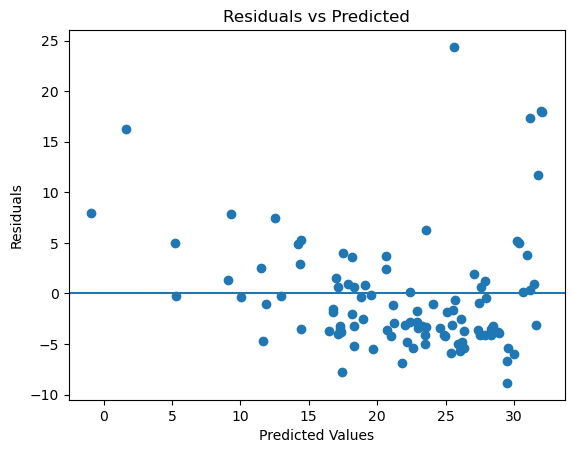

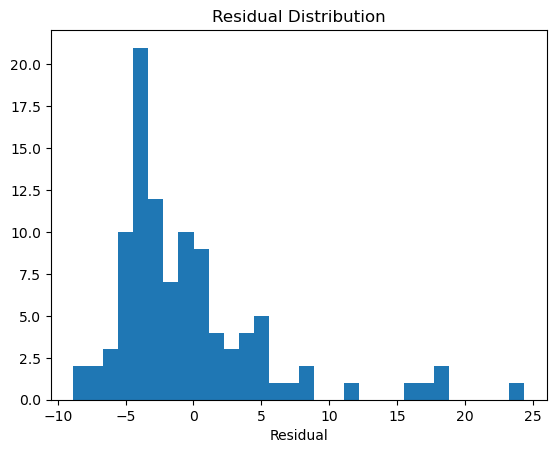


Intercept: 34.83694982031851
Coefficient for lstat: -0.966530901950353

Model Equation:
y_hat = 34.8369 + -0.9665 * lstat


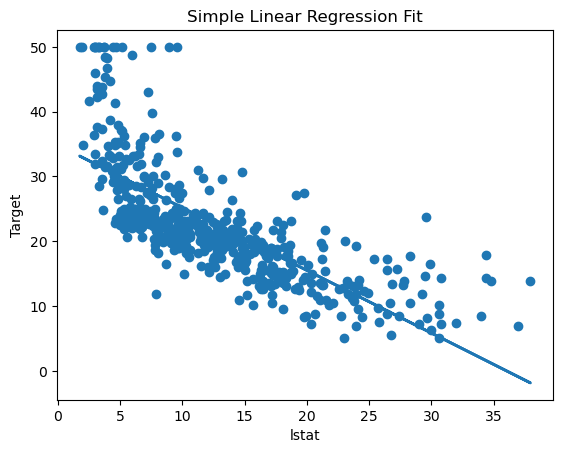

In [13]:
# Simple linear regression - strongest variable

# ================================
# SIMPLE LINEAR REGRESSION: lstat
# ================================

# Take all columns except target as predictor columns
predictor_columns = [c for c in df.columns if c != 'medv']
# Load the dataset as a pandas data frame
X1 = pd.DataFrame(df, columns = predictor_columns)
# Target
y1 = df['medv']


# -------------------------------
# Prepare Data
# -------------------------------
X = X1[['lstat']]   # ensure 2D
y = y1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Fit Model (sklearn)
# -------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -------------------------------
# Metrics
# -------------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test R²:", r2)
print("Test RMSE:", rmse)

# -------------------------------
# Cross Validation
# -------------------------------
cv5 = cross_val_score(model, X, y, cv=5, scoring='r2')
cv10 = cross_val_score(model, X, y, cv=10, scoring='r2')

print("\nCV=5 Mean R²:", cv5.mean(), "Std:", cv5.std())
print("CV=10 Mean R²:", cv10.mean(), "Std:", cv10.std())

# -------------------------------
# Bias-Variance Check
# -------------------------------
train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("\nTrain R²:", train_r2)
print("Test R²:", r2)

if train_r2 - r2 > 0.1:
    print("Potential Overfitting (High Variance)")
elif r2 < 0.5:
    print("Potential Underfitting (High Bias)")
else:
    print("Balanced Bias-Variance")

# -------------------------------
# Residuals
# -------------------------------
residuals = y_test - y_pred

# Residual vs Predicted
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Residual Distribution
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()


# -------------------------------
# Feature Influence
# -------------------------------
print("\nIntercept:", model.intercept_)
print("Coefficient for lstat:", model.coef_[0])

# -------------------------------
# Model Interpretability
# -------------------------------
print("\nModel Equation:")
print(f"y_hat = {model.intercept_:.4f} + {model.coef_[0]:.4f} * lstat")

# Visual Regression Line
plt.figure()
plt.scatter(X, y)
plt.plot(X, model.predict(X), linewidth=2)
plt.xlabel("lstat")
plt.ylabel("Target")
plt.title("Simple Linear Regression Fit")
plt.show()


In [14]:
# Forward Feature Selection

In [15]:
# Take all columns except target as predictor columns
predictor_columns = [c for c in df.columns if c != 'medv']
# Load the dataset as a pandas data frame
X2 = pd.DataFrame(df, columns = predictor_columns)
# Target
y2 = df['medv']

Selected Features: ['lstat', 'rm', 'ptratio', 'dis', 'nox', 'chas', 'b', 'zn', 'crim', 'rad', 'tax', 'indus', 'age']

Test R²: 0.6687594935356348
Adjusted R²: 0.6198262368988536
Test RMSE: 4.9286021826653155

CV=5 Mean R²: 0.3532759243958716 Std: 0.376567839332638
CV=10 Mean R²: 0.20252899006057495 Std: 0.5952960169512096

Train R²: 0.7508856358979673
Test R²: 0.6687594935356348
Balanced Bias-Variance


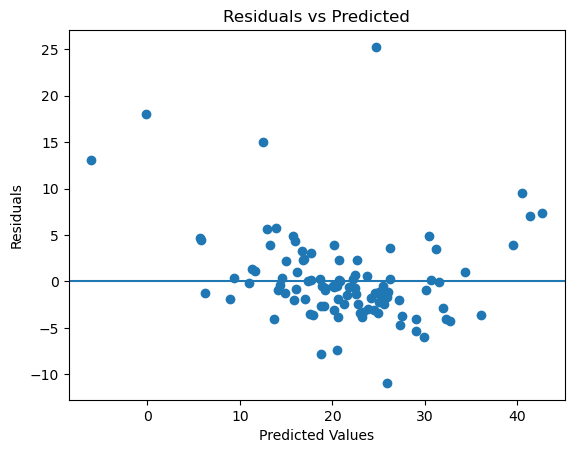

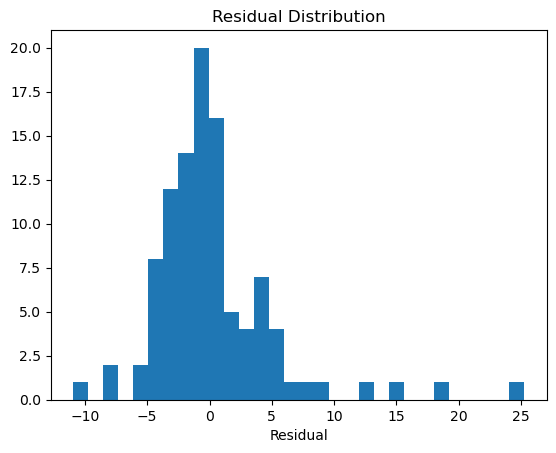


Feature Coefficients:
    Feature  Coefficient
4       nox   -17.202633
1        rm     4.438835
5      chas     2.784438
3       dis    -1.447865
2   ptratio    -0.915456
0     lstat    -0.508571
9       rad     0.262430
8      crim    -0.113056
11    indus     0.040381
7        zn     0.030110
6         b     0.012351
10      tax    -0.010647
12      age    -0.006296

Model Equation:
y_hat = 30.2468 + (-0.5086 * lstat) + (4.4388 * rm) + (-0.9155 * ptratio) + (-1.4479 * dis) + (-17.2026 * nox) + (2.7844 * chas) + (0.0124 * b) + (0.0301 * zn) + (-0.1131 * crim) + (0.2624 * rad) + (-0.0106 * tax) + (0.0404 * indus) + (-0.0063 * age)


In [16]:
# ======================================================
# FORWARD FEATURE SELECTION + LINEAR REGRESSION
# Dataset: X2 (predictors), y2 (target)
# ======================================================


# -----------------------------
# Prepare Data
# -----------------------------
X = X2.copy()
y = y2

# -----------------------------
# Forward Feature Selection
# -----------------------------
remaining_features = list(X.columns)
selected_features = []
current_score = 0
best_new_score = 0

while remaining_features:
    scores_with_candidates = []
    
    for candidate in remaining_features:
        features_to_test = selected_features + [candidate]
        model = LinearRegression()
        model.fit(X[features_to_test], y)
        score = model.score(X[features_to_test], y)
        scores_with_candidates.append((score, candidate))
    
    scores_with_candidates.sort()
    best_new_score, best_candidate = scores_with_candidates.pop()
    
    if best_new_score > current_score:
        remaining_features.remove(best_candidate)
        selected_features.append(best_candidate)
        current_score = best_new_score
    else:
        break

print("Selected Features:", selected_features)

# -----------------------------
# Train/Test Split
# -----------------------------
X_selected = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# -----------------------------
# Fit Final Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------
# Metrics
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\nTest R²:", r2)
print("Adjusted R²:", adj_r2)
print("Test RMSE:", rmse)

# -----------------------------
# Cross Validation
# -----------------------------
cv5 = cross_val_score(model, X_selected, y, cv=5, scoring='r2')
cv10 = cross_val_score(model, X_selected, y, cv=10, scoring='r2')

print("\nCV=5 Mean R²:", cv5.mean(), "Std:", cv5.std())
print("CV=10 Mean R²:", cv10.mean(), "Std:", cv10.std())

# -----------------------------
# Bias-Variance Check
# -----------------------------
train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("\nTrain R²:", train_r2)
print("Test R²:", r2)

if train_r2 - r2 > 0.1:
    print("Possible Overfitting (High Variance)")
elif r2 < 0.5:
    print("Possible Underfitting (High Bias)")
else:
    print("Balanced Bias-Variance")

# -----------------------------
# Residual Analysis
# -----------------------------
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()


# -----------------------------
# Feature Influence
# -----------------------------
coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("\nFeature Coefficients:")
print(coef_df)

# -----------------------------
# Model Interpretability
# -----------------------------
print("\nModel Equation:")
equation = f"y_hat = {model.intercept_:.4f}"
for feature, coef in zip(selected_features, model.coef_):
    equation += f" + ({coef:.4f} * {feature})"
print(equation)


In [17]:
# Full Model Regression

In [18]:
# Take all columns except target as predictor columns
predictor_columns = [c for c in df.columns if c != 'medv']
# Load the dataset as a pandas data frame
X3 = pd.DataFrame(df, columns = predictor_columns)
# Target
y3 = df['medv']

Test R²: 0.6687594935356317
Adjusted R²: 0.6198262368988501
Test RMSE: 4.928602182665339

CV=5 Mean R²: 0.3532759243958762 Std: 0.37656783933262383
CV=10 Mean R²: 0.20252899006056796 Std: 0.5952960169512175

Train R²: 0.7508856358979673
Test R²: 0.6687594935356317
Balanced Bias-Variance


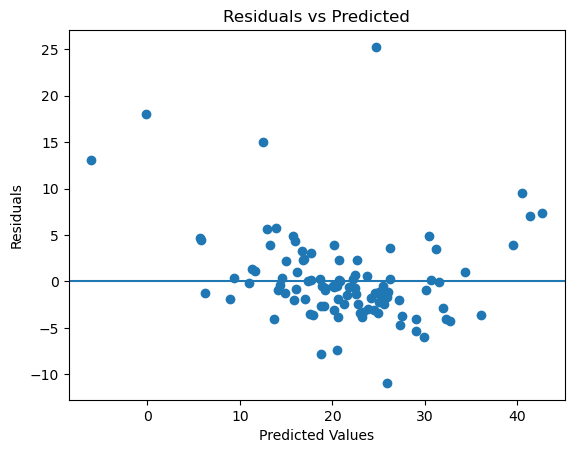

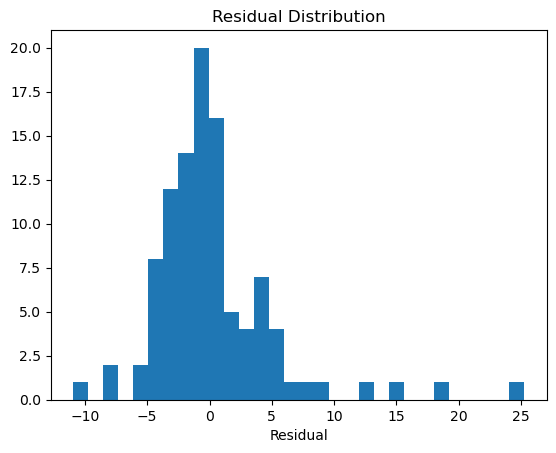


Feature Coefficients (Ranked by Magnitude):
    Feature  Coefficient
4       nox   -17.202633
5        rm     4.438835
3      chas     2.784438
7       dis    -1.447865
10  ptratio    -0.915456
12    lstat    -0.508571
8       rad     0.262430
0      crim    -0.113056
2     indus     0.040381
1        zn     0.030110
11        b     0.012351
9       tax    -0.010647
6       age    -0.006296

Model Equation:
y_hat = 30.2468 + (-0.1131 * crim) + (0.0301 * zn) + (0.0404 * indus) + (2.7844 * chas) + (-17.2026 * nox) + (4.4388 * rm) + (-0.0063 * age) + (-1.4479 * dis) + (0.2624 * rad) + (-0.0106 * tax) + (-0.9155 * ptratio) + (0.0124 * b) + (-0.5086 * lstat)


In [20]:
# ======================================================
# FULL MULTIPLE LINEAR REGRESSION MODEL
# Dataset: X3 (predictors), y3 (target)
# ======================================================

# -----------------------------
# Prepare Data
# -----------------------------
X = X3.copy()
y = y3

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Fit Full Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------
# Performance Metrics
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Test R²:", r2)
print("Adjusted R²:", adj_r2)
print("Test RMSE:", rmse)

# -----------------------------
# Cross Validation
# -----------------------------
cv5 = cross_val_score(model, X, y, cv=5, scoring='r2')
cv10 = cross_val_score(model, X, y, cv=10, scoring='r2')

print("\nCV=5 Mean R²:", cv5.mean(), "Std:", cv5.std())
print("CV=10 Mean R²:", cv10.mean(), "Std:", cv10.std())

# -----------------------------
# Bias-Variance Analysis
# -----------------------------
train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("\nTrain R²:", train_r2)
print("Test R²:", r2)

if train_r2 - r2 > 0.1:
    print("Potential Overfitting (High Variance)")
elif r2 < 0.5:
    print("Potential Underfitting (High Bias)")
else:
    print("Balanced Bias-Variance")

# -----------------------------
# Residual Analysis
# -----------------------------
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

# -----------------------------
# Feature Influence
# -----------------------------
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("\nFeature Coefficients (Ranked by Magnitude):")
print(coef_df)

# -----------------------------
# Model Interpretability (Statsmodels)
# -----------------------------
# X_sm = sm.add_constant(X)
# model_sm = sm.OLS(y, X_sm).fit()

# print("\nStatsmodels Full Summary:")
# print(model_sm.summary())

print("\nModel Equation:")
equation = f"y_hat = {model.intercept_:.4f}"
for feature, coef in zip(X.columns, model.coef_):
    equation += f" + ({coef:.4f} * {feature})"
print(equation)


In [ ]:
# Random Forest Regression

Test R²: 0.8791057217425063
Adjusted R²: 0.8612463397271948
Test RMSE: 2.977521584650359
OOB R²: 0.8407797288917938

CV=5 Mean R²: 0.6251511563494508 Std: 0.21137045355963135
CV=10 Mean R²: 0.4888807023952061 Std: 0.3756344140529044

Train R²: 0.9781775987586625
Test R²: 0.8791057217425063
Balanced Bias-Variance


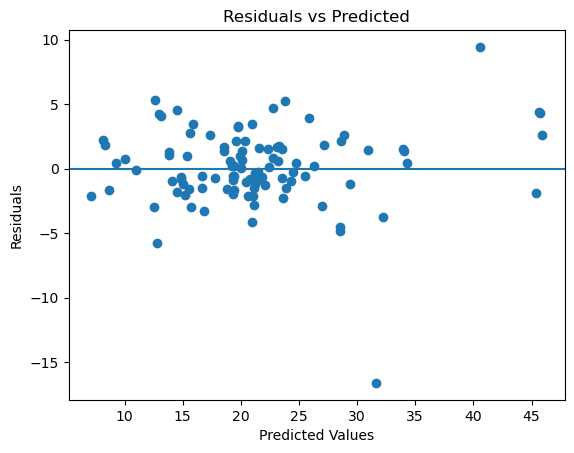

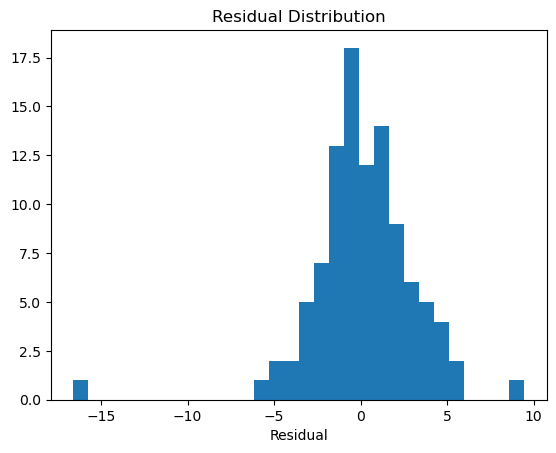


Top Influential Observations:
     Actual  Predicted  Residual  Abs_Error
375    15.0    31.5994  -16.5994    16.5994
371    50.0    40.5564    9.4436     9.4436
489     7.0    12.7724   -5.7724     5.7724
412    17.9    12.5850    5.3150     5.3150
278    29.1    23.8092    5.2908     5.2908

Feature Importance (Gini):
    Feature  Gini Importance
5        rm         0.480887
12    lstat         0.334585
7       dis         0.056765
0      crim         0.037667
4       nox         0.016676
10  ptratio         0.015973
9       tax         0.015528
6       age         0.015116
11        b         0.012675
2     indus         0.006671
8       rad         0.004369
1        zn         0.001841
3      chas         0.001247


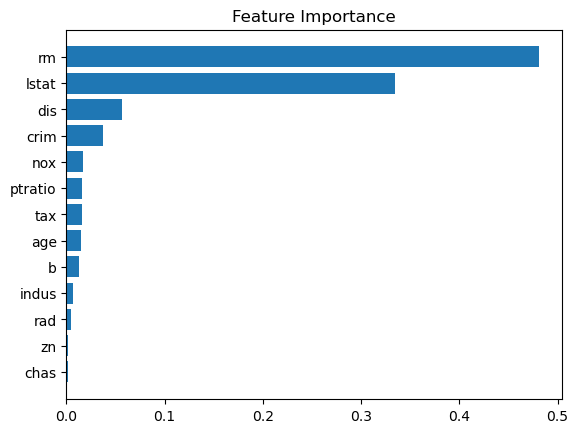


Permutation Importance:
    Feature  Permutation Importance
12    lstat                0.478757
5        rm                0.464103
7       dis                0.085105
0      crim                0.038373
4       nox                0.030654
10  ptratio                0.023451
6       age                0.013938
9       tax                0.008656
2     indus                0.002914
8       rad                0.002357
11        b                0.001556
1        zn                0.000611
3      chas                0.000326

Model Interpretability Notes:
- Random Forest captures nonlinearities & interactions.
- Top features identified above drive predictions most strongly.
- OOB score approximates cross-validation performance.


In [21]:
# Take all columns except target as predictor columns
predictor_columns = [c for c in df.columns if c != 'medv']
# Load the dataset as a pandas data frame
X20 = pd.DataFrame(df, columns = predictor_columns)
# Target
y20 = df['medv']

# ==========================================
# RANDOM FOREST REGRESSION - FULL WORKFLOW
# Dataset: X20 (predictors), y20 (target)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

# -----------------------------
# Train / Test Split
# -----------------------------
X = X20
y = y20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = rf.predict(X_test)

# -----------------------------
# Metrics
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Adjusted R²
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Test R²:", r2)
print("Adjusted R²:", adj_r2)
print("Test RMSE:", rmse)
print("OOB R²:", rf.oob_score_)

# -----------------------------
# Cross Validation
# -----------------------------
cv5 = cross_val_score(rf, X, y, cv=5, scoring='r2')
cv10 = cross_val_score(rf, X, y, cv=10, scoring='r2')

print("\nCV=5 Mean R²:", cv5.mean(), "Std:", cv5.std())
print("CV=10 Mean R²:", cv10.mean(), "Std:", cv10.std())

# -----------------------------
# Bias-Variance Check
# -----------------------------
train_pred = rf.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("\nTrain R²:", train_r2)
print("Test R²:", r2)

if train_r2 - r2 > 0.1:
    print("Potential Overfitting (High Variance)")
elif r2 < 0.5:
    print("Potential Underfitting (High Bias)")
else:
    print("Balanced Bias-Variance")

# -----------------------------
# Residual Analysis
# -----------------------------
residuals = y_test - y_pred

# Residual vs Predicted
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Residual Distribution
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

# -----------------------------
# Influence Diagnostics
# -----------------------------
abs_errors = np.abs(residuals)
influence_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals,
    "Abs_Error": abs_errors
}).sort_values("Abs_Error", ascending=False)

print("\nTop Influential Observations:")
print(influence_df.head())

# -----------------------------
# Feature Importance (Gini)
# -----------------------------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Gini Importance": rf.feature_importances_
}).sort_values("Gini Importance", ascending=False)

print("\nFeature Importance (Gini):")
print(importance_df)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Gini Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

# -----------------------------
# Permutation Importance
# -----------------------------
perm = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance": perm.importances_mean
}).sort_values("Permutation Importance", ascending=False)

print("\nPermutation Importance:")
print(perm_df)

# -----------------------------
# Model Interpretability
# -----------------------------
print("\nModel Interpretability Notes:")
print("- Random Forest captures nonlinearities & interactions.")
print("- Top features identified above drive predictions most strongly.")
print("- OOB score approximates cross-validation performance.")


In [ ]:
# Lasso Regression

In [23]:
# Take all columns except target as predictor columns
predictor_columns = [c for c in df.columns if c != 'medv']
# Load the dataset as a pandas data frame
X4 = pd.DataFrame(df, columns = predictor_columns)
# Target
y4 = df['medv']


Best Alpha: 0.006863892263379668
Test R²: 0.6683883969336302
Adjusted R²: 0.6194003192079165
Test RMSE: 4.931362224853925

CV=5 Mean R²: 0.39178079038455627 Std: 0.32470654684276057
CV=10 Mean R²: 0.2849320530787801 Std: 0.47698247066182403

Train R²: 0.750846841458309
Test R²: 0.6683883969336302
Balanced Bias-Variance


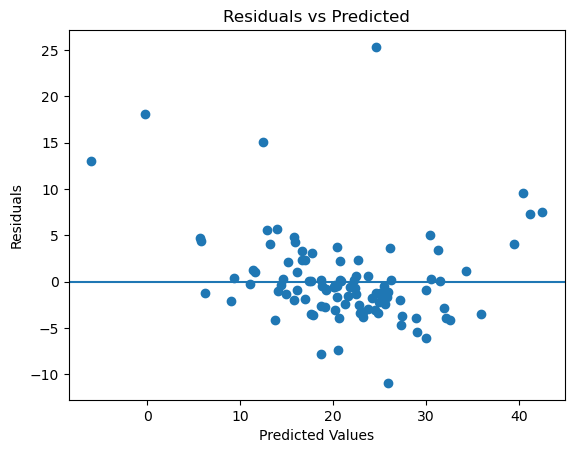

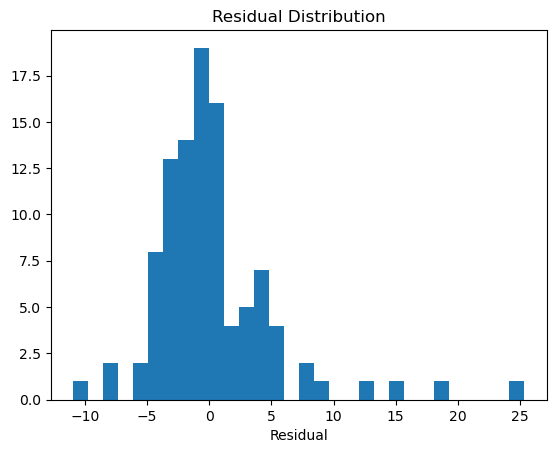


Top High-Error Observations:
     Actual  Predicted   Residual  Abs_Error
371    50.0  24.681272  25.318728  25.318728
412    17.9  -0.179548  18.079548  18.079548
365    27.5  12.455522  15.044478  15.044478
414     7.0  -6.013263  13.013263  13.013263
375    15.0  25.924814 -10.924814  10.924814

Lasso Feature Coefficients:
    Feature  Coefficient  Abs_Coefficient
12    lstat    -3.610072         3.610072
5        rm     3.149505         3.149505
7       dis    -3.033683         3.033683
8       rad     2.127566         2.127566
10  ptratio    -2.025009         2.025009
4       nox    -1.978859         1.978859
9       tax    -1.643649         1.643649
11        b     1.121376         1.121376
0      crim    -0.983042         0.983042
3      chas     0.719674         0.719674
1        zn     0.662207         0.662207
2     indus     0.215572         0.215572
6       age    -0.160356         0.160356

Permutation Importance:
    Feature  Permutation Importance
12    lstat           

In [24]:
# ======================================================
# LASSO REGRESSION - FULL WORKFLOW
# Dataset: X20 (predictors), y20 (target)
# ======================================================


# -----------------------------
# Prepare Data
# -----------------------------
X = X4.copy()
y = y4

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Lasso with Cross-Validated Alpha
# -----------------------------
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, random_state=42))
])

lasso_pipeline.fit(X_train, y_train)

y_pred = lasso_pipeline.predict(X_test)

# -----------------------------
# Performance Metrics
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Best Alpha:", lasso_pipeline.named_steps['lasso'].alpha_)
print("Test R²:", r2)
print("Adjusted R²:", adj_r2)
print("Test RMSE:", rmse)

# -----------------------------
# Cross Validation
# -----------------------------
cv5 = cross_val_score(lasso_pipeline, X, y, cv=5, scoring='r2')
cv10 = cross_val_score(lasso_pipeline, X, y, cv=10, scoring='r2')

print("\nCV=5 Mean R²:", cv5.mean(), "Std:", cv5.std())
print("CV=10 Mean R²:", cv10.mean(), "Std:", cv10.std())

# -----------------------------
# Bias-Variance Analysis
# -----------------------------
train_pred = lasso_pipeline.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("\nTrain R²:", train_r2)
print("Test R²:", r2)

if train_r2 - r2 > 0.1:
    print("Potential Overfitting (High Variance)")
elif r2 < 0.5:
    print("Potential Underfitting (High Bias)")
else:
    print("Balanced Bias-Variance")

# -----------------------------
# Residual Analysis
# -----------------------------
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

# -----------------------------
# Influence Diagnostics
# -----------------------------
abs_errors = np.abs(residuals)
influence_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals,
    "Abs_Error": abs_errors
}).sort_values("Abs_Error", ascending=False)

print("\nTop High-Error Observations:")
print(influence_df.head())

# -----------------------------
# Feature Influence
# -----------------------------
lasso_model = lasso_pipeline.named_steps['lasso']
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

coef_df["Abs_Coefficient"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

print("\nLasso Feature Coefficients:")
print(coef_df)

# -----------------------------
# Permutation Importance
# -----------------------------
perm = permutation_importance(
    lasso_pipeline, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance": perm.importances_mean
}).sort_values("Permutation Importance", ascending=False)

print("\nPermutation Importance:")
print(perm_df)

# -----------------------------
# Model Interpretability
# -----------------------------
selected_features = coef_df[coef_df["Coefficient"] != 0]

print("\nSelected Features (Non-Zero Coefficients):")
print(selected_features[["Feature", "Coefficient"]])

print("\nModel Interpretation:")
print("- Lasso performs L1 regularization.")
print("- Coefficients shrunk toward zero.")
print("- Some features eliminated (automatic feature selection).")


In [26]:
# Ridge Regression

In [27]:
# Take all columns except target as predictor columns
predictor_columns = [c for c in df.columns if c != 'medv']
# Load the dataset as a pandas data frame
X5 = pd.DataFrame(df, columns = predictor_columns)
# Target
y5 = df['medv']


Best Alpha: 2.782559402207126
Test R²: 0.667935555866449
Adjusted R²: 0.6188805811649019
Test RMSE: 4.934728152729692

CV=5 Mean R²: 0.4620262515175225 Std: 0.2624047294957749
CV=10 Mean R²: 0.3528077474337879 Std: 0.3775110075293354

Train R²: 0.7507768518427961
Test R²: 0.667935555866449
Balanced Bias-Variance


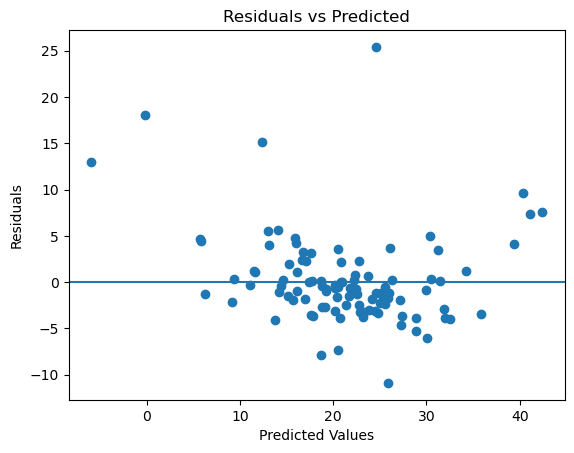

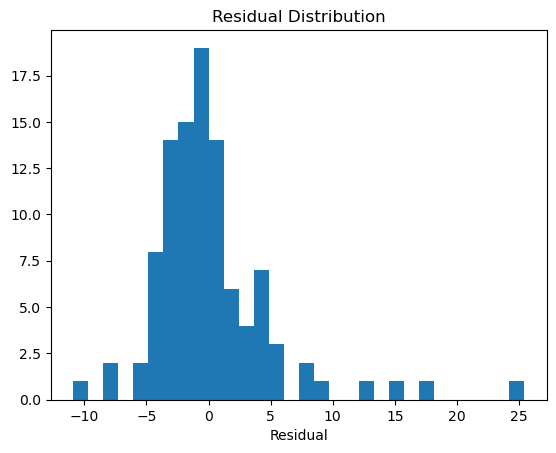


Top High-Error Observations:
     Actual  Predicted   Residual  Abs_Error
371    50.0  24.583404  25.416596  25.416596
412    17.9  -0.189639  18.089639  18.089639
365    27.5  12.347322  15.152678  15.152678
414     7.0  -5.953234  12.953234  12.953234
375    15.0  25.891834 -10.891834  10.891834

Ridge Feature Coefficients (Shrunk):
    Feature  Coefficient  Abs_Coefficient
12    lstat    -3.577112         3.577112
5        rm     3.161437         3.161437
7       dis    -2.981941         2.981941
8       rad     2.046855         2.046855
10  ptratio    -2.010950         2.010950
4       nox    -1.937316         1.937316
9       tax    -1.581748         1.581748
11        b     1.123015         1.123015
0      crim    -0.975698         0.975698
3      chas     0.728511         0.728511
1        zn     0.647435         0.647435
2     indus     0.210419         0.210419
6       age    -0.179078         0.179078

Permutation Importance:
    Feature  Permutation Importance
12    lstat  

In [28]:
# ======================================================
# RIDGE REGRESSION - FULL WORKFLOW
# Dataset: X5 (predictors), y5 (target)
# ======================================================

# -----------------------------
# Prepare Data
# -----------------------------
X = X5.copy()
y = y5

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Ridge with Cross-Validated Alpha
# -----------------------------
alphas = np.logspace(-4, 4, 100)

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, cv=5))
])

ridge_pipeline.fit(X_train, y_train)

y_pred = ridge_pipeline.predict(X_test)

# -----------------------------
# Performance Metrics
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Best Alpha:", ridge_pipeline.named_steps['ridge'].alpha_)
print("Test R²:", r2)
print("Adjusted R²:", adj_r2)
print("Test RMSE:", rmse)

# -----------------------------
# Cross Validation
# -----------------------------
cv5 = cross_val_score(ridge_pipeline, X, y, cv=5, scoring='r2')
cv10 = cross_val_score(ridge_pipeline, X, y, cv=10, scoring='r2')

print("\nCV=5 Mean R²:", cv5.mean(), "Std:", cv5.std())
print("CV=10 Mean R²:", cv10.mean(), "Std:", cv10.std())

# -----------------------------
# Bias-Variance Analysis
# -----------------------------
train_pred = ridge_pipeline.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("\nTrain R²:", train_r2)
print("Test R²:", r2)

if train_r2 - r2 > 0.1:
    print("Potential Overfitting (High Variance)")
elif r2 < 0.5:
    print("Potential Underfitting (High Bias)")
else:
    print("Balanced Bias-Variance")

# -----------------------------
# Residual Analysis
# -----------------------------
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

# -----------------------------
# Influence Diagnostics
# -----------------------------
abs_errors = np.abs(residuals)
influence_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals,
    "Abs_Error": abs_errors
}).sort_values("Abs_Error", ascending=False)

print("\nTop High-Error Observations:")
print(influence_df.head())

# -----------------------------
# Feature Influence
# -----------------------------
ridge_model = ridge_pipeline.named_steps['ridge']
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_
})

coef_df["Abs_Coefficient"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

print("\nRidge Feature Coefficients (Shrunk):")
print(coef_df)

# -----------------------------
# Permutation Importance
# -----------------------------
perm = permutation_importance(
    ridge_pipeline, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance": perm.importances_mean
}).sort_values("Permutation Importance", ascending=False)

print("\nPermutation Importance:")
print(perm_df)

# -----------------------------
# Model Interpretability
# -----------------------------
print("\nModel Interpretation:")
print("- Ridge applies L2 regularization.")
print("- Coefficients are shrunk but not eliminated.")
print("- Reduces multicollinearity impact.")
print("- Improves generalization vs full OLS.")


In [29]:
# Gradient Boosting Regressor

In [30]:
# Take all columns except target as predictor columns
predictor_columns = [c for c in df.columns if c != 'medv']
# Load the dataset as a pandas data frame
X6 = pd.DataFrame(df, columns = predictor_columns)
# Target
y6 = df['medv']


Test R²: 0.9137718929980266
Adjusted R²: 0.9010336499181897
Test RMSE: 2.514643772228552

CV=5 Mean R²: 0.6658967764088929 Std: 0.15675232022010183
CV=10 Mean R²: 0.44665559815208083 Std: 0.48204965440354003

Train R²: 0.994030788460668
Test R²: 0.9137718929980266
Balanced Bias-Variance


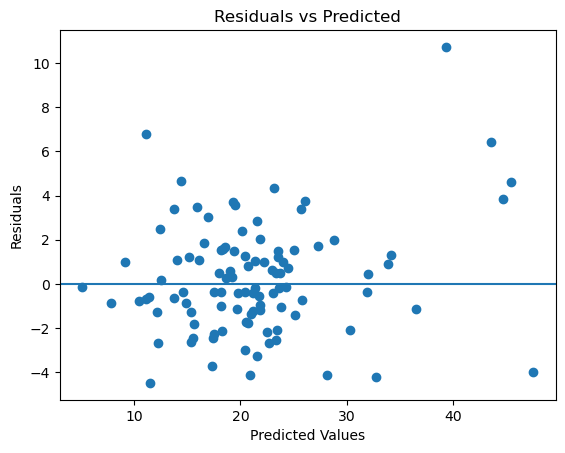

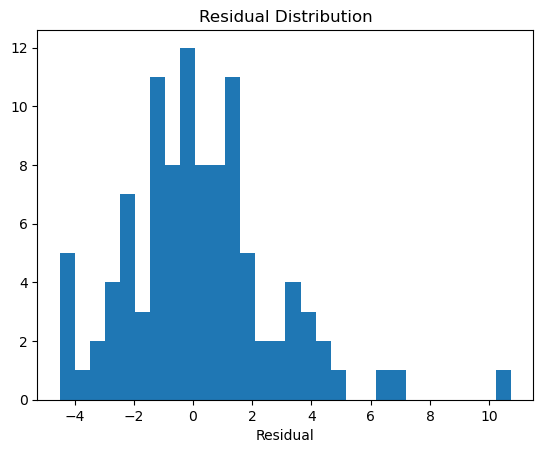


Top High-Error Observations:
     Actual  Predicted   Residual  Abs_Error
371    50.0  39.266498  10.733502  10.733502
412    17.9  11.096297   6.803703   6.803703
204    50.0  43.554936   6.445064   6.445064
467    19.1  14.422192   4.677808   4.677808
195    50.0  45.384600   4.615400   4.615400

Feature Importance (Tree-Based):
    Feature  Feature Importance
5        rm            0.406142
12    lstat            0.374462
7       dis            0.072480
4       nox            0.034583
10  ptratio            0.031870
0      crim            0.027173
6       age            0.021013
11        b            0.013456
9       tax            0.013355
8       rad            0.002484
2     indus            0.002031
1        zn            0.000669
3      chas            0.000282


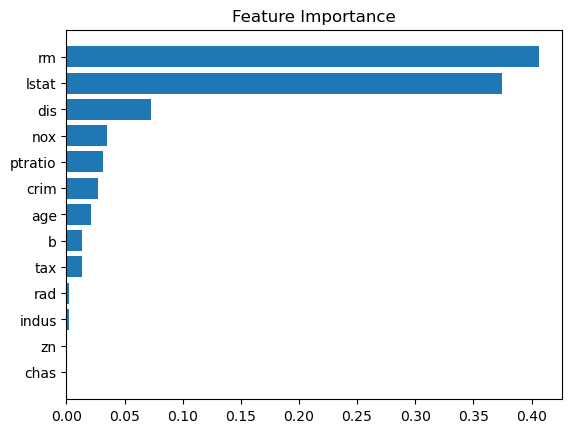


Permutation Importance:
    Feature  Permutation Importance
12    lstat                0.484144
5        rm                0.378776
7       dis                0.144583
4       nox                0.051316
6       age                0.045842
0      crim                0.032913
10  ptratio                0.028686
11        b                0.013536
9       tax                0.013261
2     indus                0.004815
1        zn                0.004650
8       rad                0.003667
3      chas                0.000558

Model Interpretation:
- Gradient Boosting builds trees sequentially.
- Each tree corrects residuals from previous trees.
- Captures nonlinearities and interactions.
- Feature importance ranks predictive drivers.


In [31]:
# ======================================================
# GRADIENT BOOSTING REGRESSION - FULL WORKFLOW
# Dataset: X6 (predictors), y6 (target)
# ======================================================

# -----------------------------
# Prepare Data
# -----------------------------
X = X6.copy()
y = y6

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Model
# -----------------------------
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

# -----------------------------
# Performance Metrics
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Test R²:", r2)
print("Adjusted R²:", adj_r2)
print("Test RMSE:", rmse)

# -----------------------------
# Cross Validation
# -----------------------------
cv5 = cross_val_score(gbr, X, y, cv=5, scoring='r2')
cv10 = cross_val_score(gbr, X, y, cv=10, scoring='r2')

print("\nCV=5 Mean R²:", cv5.mean(), "Std:", cv5.std())
print("CV=10 Mean R²:", cv10.mean(), "Std:", cv10.std())

# -----------------------------
# Bias-Variance Analysis
# -----------------------------
train_pred = gbr.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("\nTrain R²:", train_r2)
print("Test R²:", r2)

if train_r2 - r2 > 0.1:
    print("Potential Overfitting (High Variance)")
elif r2 < 0.5:
    print("Potential Underfitting (High Bias)")
else:
    print("Balanced Bias-Variance")

# -----------------------------
# Residual Analysis
# -----------------------------
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.title("Residual Distribution")
plt.show()

# -----------------------------
# Influence Diagnostics
# -----------------------------
abs_errors = np.abs(residuals)
influence_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals,
    "Abs_Error": abs_errors
}).sort_values("Abs_Error", ascending=False)

print("\nTop High-Error Observations:")
print(influence_df.head())

# -----------------------------
# Feature Influence (Built-in)
# -----------------------------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Feature Importance": gbr.feature_importances_
}).sort_values("Feature Importance", ascending=False)

print("\nFeature Importance (Tree-Based):")
print(importance_df)

plt.figure()
plt.barh(importance_df["Feature"], importance_df["Feature Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

# -----------------------------
# Permutation Importance
# -----------------------------
perm = permutation_importance(
    gbr, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Permutation Importance": perm.importances_mean
}).sort_values("Permutation Importance", ascending=False)

print("\nPermutation Importance:")
print(perm_df)

# -----------------------------
# Model Interpretability Notes
# -----------------------------
print("\nModel Interpretation:")
print("- Gradient Boosting builds trees sequentially.")
print("- Each tree corrects residuals from previous trees.")
print("- Captures nonlinearities and interactions.")
print("- Feature importance ranks predictive drivers.")
